Step(1): Load Data

In [38]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# Data : https://www.kaggle.com/datasets/hassan06/nslkdd

In [40]:
df = pd.read_csv("/content/KDDTrain+.txt", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Step(2) : Add Column Names

In [41]:
columns = [
"duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
"count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
"srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
"dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
"dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate",
"dst_host_srv_serror_rate","dst_host_rerror_rate",
"dst_host_srv_rerror_rate","label","difficulty_level"
]

df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Step(3) : Understand Data


> Description:
This step loads the NSL-KDD dataset and explores its structure, number of rows, columns, data types, and target variable.



In [42]:
df.shape

(125973, 43)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [44]:
df['label'].value_counts()

,count
label,
normal,67343
neptune,41214
satan,3633
ipsweep,3599
portsweep,2931
smurf,2646
nmap,1493
back,956
teardrop,892


Step(4) : Exploratory Data Analysis (EDA)

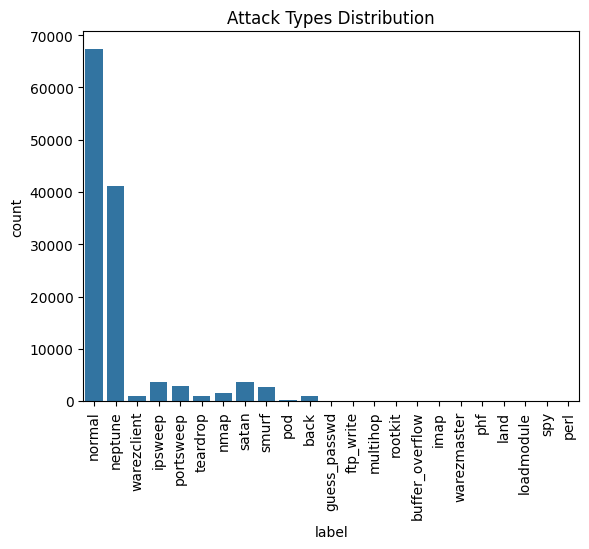

In [45]:
sns.countplot(x='label', data=df)
plt.title("Attack Types Distribution")
plt.xticks(rotation=90)
plt.show()

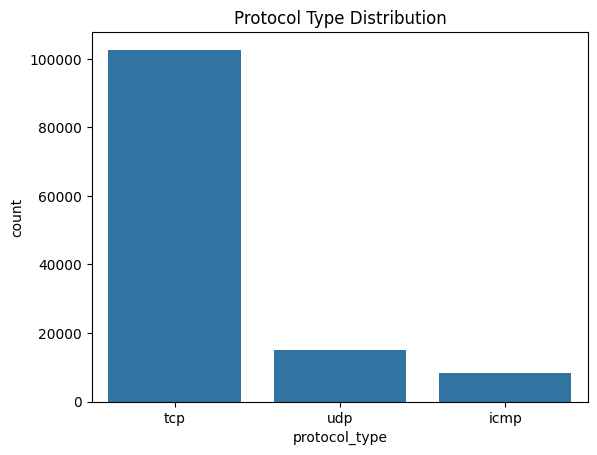

In [46]:
sns.countplot(x='protocol_type', data=df)
plt.title("Protocol Type Distribution")
plt.show()

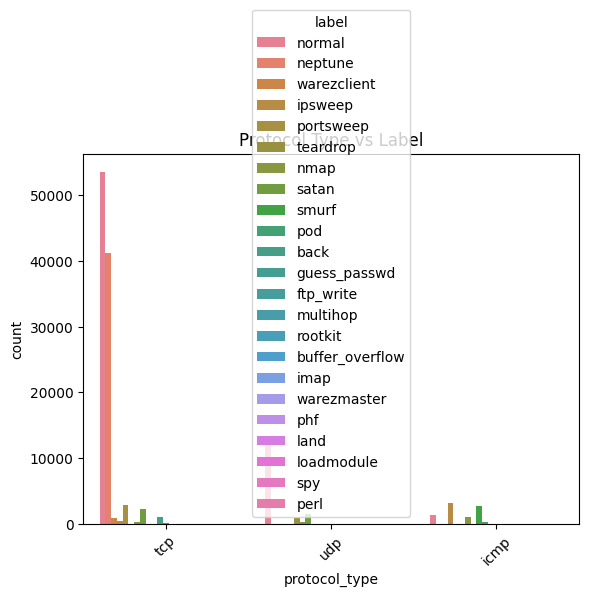

In [47]:
sns.countplot(x='protocol_type', hue='label', data=df)
plt.title("Protocol Type vs Label")
plt.xticks(rotation=45)
plt.show()

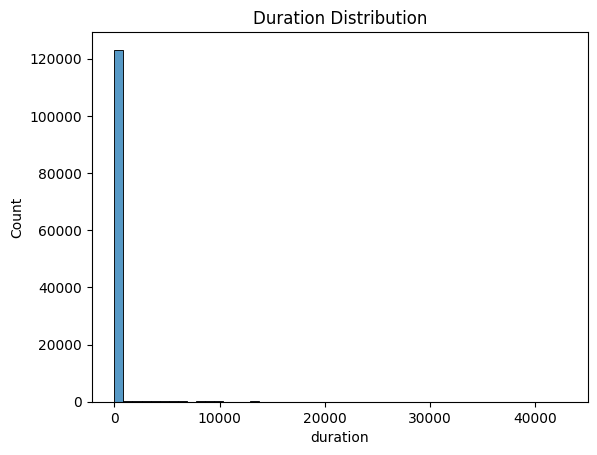

In [48]:
sns.histplot(df['duration'], bins=50)
plt.title("Duration Distribution")
plt.show()

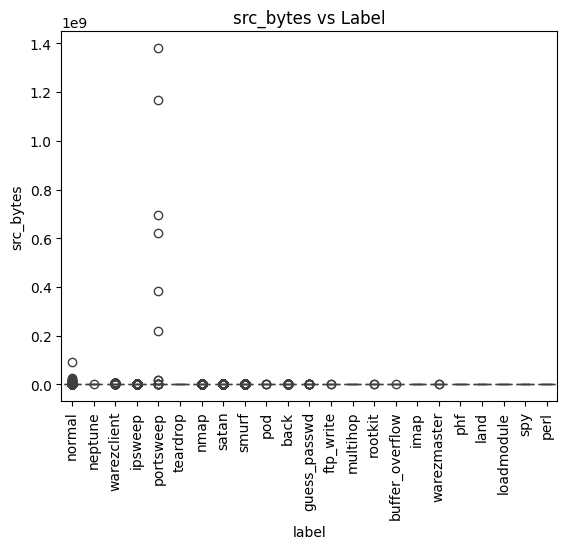

In [49]:
sns.boxplot(x='label', y='src_bytes', data=df)
plt.title("src_bytes vs Label")
plt.xticks(rotation=90)
plt.show()

Step(5) Data Cleaning

In [50]:
df.isnull().sum().sum()

np.int64(0)

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df = df.drop_duplicates()

In [53]:
if "difficulty_level" in df.columns:
    df = df.drop("difficulty_level", axis=1)
df.dropna(inplace=True)

Step(6) : Convert Target

> نخليها Binary:
> Normal = 0
> Attack = 1



In [54]:
df['label'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
df['label'].value_counts()

,count
label,
0,67343
1,58630


Step(7) : Split X and y

In [55]:
X = df.drop("label", axis=1)
y = df["label"]

Step(8) : Train / Validation / Test Split

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Encoding (Convert text to numbers)

In [57]:
X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
X_test = pd.get_dummies(X_test)

In [58]:
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scaling (Unifying numbers)

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#  Training Models

Logistic Regression


> Description:
The Logistic Regression model achieved an accuracy of 97% on the validation set. The model performs well in detecting both normal and attack traffic, with high precision and recall scores, making it suitable for intrusion detection tasks.



In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.9731689246401355
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     10101
           1       0.98      0.96      0.97      8795

    accuracy                           0.97     18896
   macro avg       0.97      0.97      0.97     18896
weighted avg       0.97      0.97      0.97     18896



Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model_dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Validation Accuracy: 0.9929614733276884
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     10101
           1       0.99      0.99      0.99      8795

    accuracy                           0.99     18896
   macro avg       0.99      0.99      0.99     18896
weighted avg       0.99      0.99      0.99     18896



Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Validation Accuracy: 0.9971422523285352
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10101
           1       1.00      0.99      1.00      8795

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896



In [63]:
y_train_pred = model_rf.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_rf))

Train Accuracy: 0.9971762624601671
Validation Accuracy: 0.9971422523285352


Final Testing


> Final Testing Description:
The final model was evaluated on the test set and achieved 99.6% accuracy. The model demonstrated strong generalization with consistent performance across training, validation, and test datasets



In [64]:
y_test_pred = model_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.9966659610499576
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     10102
           1       1.00      0.99      1.00      8794

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896



# SMOTE


> SMOTE was applied to address class imbalance; however, the results showed no significant improvement in model performance. This indicates that the dataset was already well-balanced and the model was capable of learning effectively without additional resampling.



In [65]:
pip install imbalanced-learn

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [67]:
import collections

print("Before:", collections.Counter(y_train))
print("After:", collections.Counter(y_train_smote))

Before: Counter({0: 47140, 1: 41041})
After: Counter({1: 47140, 0: 47140})


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model_rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_rf_smote.predict(X_val)

print("SMOTE Validation Accuracy:", accuracy_score(y_val, y_pred_smote))
print(classification_report(y_val, y_pred_smote))

SMOTE Validation Accuracy: 0.9971422523285352
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10101
           1       1.00      0.99      1.00      8795

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896



In [69]:
import joblib

joblib.dump(model_rf, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.shape[1], "num_features.pkl")

['num_features.pkl']

In [70]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("num_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [71]:
import joblib

feature_names = scaler.feature_names_in_.tolist()

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']

In [72]:
from google.colab import files
files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
from sklearn.metrics import classification_report
import joblib

report = classification_report(y_test, y_test_pred, output_dict=True)

joblib.dump(report, "model_report.pkl")

['model_report.pkl']

In [74]:
joblib.dump(model_rf.feature_importances_, "feature_importance.pkl")

['feature_importance.pkl']